## Importing data:

In [1]:
import pandas as pd

train_path = '/kaggle/input/competitions/nlp-getting-started/train.csv'
test_path = '/kaggle/input/competitions/nlp-getting-started/test.csv'

train_df = pd.read_csv(train_path)
print("training set: ",train_df.shape)
display(train_df.head(3))

test_df = pd.read_csv(test_path)
print('test set: ',test_df.shape)
display(test_df.head(3))

training set:  (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1


test set:  (3263, 4)


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."


In [2]:
print(f"Total samples in the training set are: {len(train_df)}")

Total samples in the training set are: 7613


In [3]:
target = 'target'

#we'll be using bag-of-word model so we will only require text column and the target
X = train_df['text'].values
y = train_df[target].values

## Plotting word clouds:

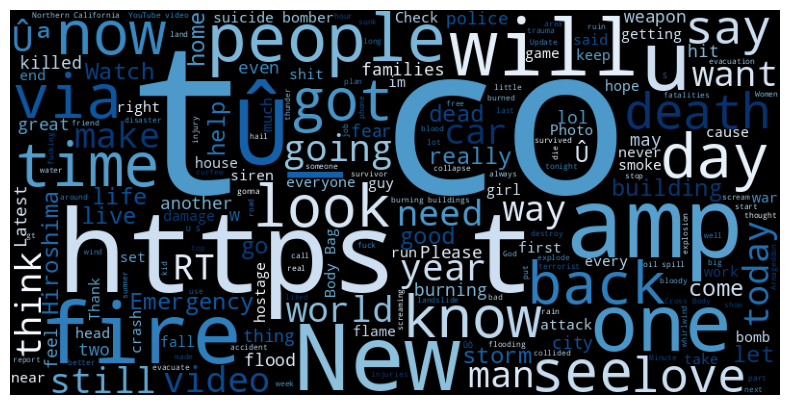

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
 
train_text = " ".join(train_df['text'])
wc  = WordCloud(height=400, 
               width=800, 
               random_state=42,
               background_color='black',
               colormap='Blues'
              ).generate(train_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

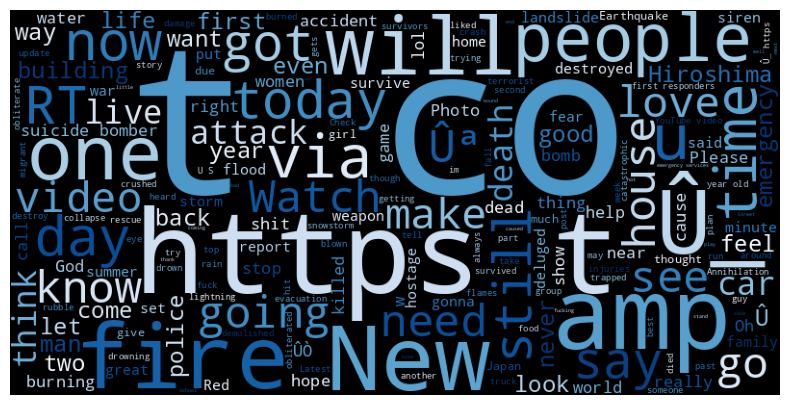

In [5]:
test_text = " ".join(test_df['text'])
wc  = WordCloud(height=400, 
               width=800, 
               random_state=42,
               background_color='black',
               colormap='Blues'
              ).generate(test_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

As can be observed from both the word clouds, they are pertty much similar, the words that frequently occure in training set are also appearing in test set.

## Preparing the data:
We'll split the train set into train/val set using **train_test_split()**, we'll have about 20% of training data in validation split.

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(X,y, 
                                               test_size=0.2,
                                               stratify=y, 
                                               random_state=42)

### Creating tf dataset

In [7]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((X_train,y_train)) 
train_ds = train_ds.batch(16)

val_ds = tf.data.Dataset.from_tensor_slices((X_val,y_val))
val_ds = val_ds.batch(16)

2026-03-15 13:38:41.726521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773581922.059524      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773581922.155873      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773581922.909754      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773581922.909793      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773581922.909796      17 computation_placer.cc:177] computation placer alr

### Uni-gram TextVectorization layer:

In [8]:
from tensorflow.keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=10000, #limits vocab to 10000 most frequent words
    output_mode = 'multi_hot' #encodes the output tokens as a multihot binary vector
)

vectorizer.adapt(X_train) #creates a vocabulary

### Processing data/Applying vectorization:

In [9]:
train_ds_uni = train_ds.map(lambda x, y: (vectorizer(x), y), 
                        num_parallel_calls=4) #to leverage multiple CPU cores

val_ds_uni = val_ds.map(lambda x, y: (vectorizer(x), y), 
                    num_parallel_calls=4)

In [10]:
#inspecting a result of vectorizer util
for x,y in train_ds_uni:
    print(x,y)
    break

tf.Tensor(
[[1 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]], shape=(16, 10000), dtype=int64) tf.Tensor([1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1], shape=(16,), dtype=int64)


In [11]:
len(train_ds_uni) #gives number of batches for training

381

## Model-building utility:
We'll be writing a reuable model-building function that we'll use for all of our experiments in this notebook.

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(max_tokens=10000):
    inputs = keras.Input(shape=(max_tokens,))
    x = layers.Dense(16, activation='relu') (inputs)
    x = layers.Dropout(0.5) (x)
    outputs = layers.Dense(1, activation='sigmoid') (x)
    
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    
    return model

## Training the model on uni-gram dataset:

In [13]:
model = get_model()
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint('unigram_model.keras', save_best_only=True)
]

model.fit(train_ds_uni,
        validation_data = val_ds_uni,
        epochs=35,
        callbacks=callbacks)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,033 (625.13 KB)

 Trainable params: 160,033 (625.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6338 - loss: 0.6503 - val_accuracy: 0.7722 - val_loss: 0.5338
Epoch 2/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7688 - loss: 0.5280 - val_accuracy: 0.8017 - val_loss: 0.4777
Epoch 3/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8056 - loss: 0.4659 - val_accuracy: 0.8102 - val_loss: 0.4572
Epoch 4/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8179 - loss: 0.4317 - val_accuracy: 0.8096 - val_loss: 0.4500
Epoch 5/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8353 - loss: 0.4087 - val_accuracy: 0.8096 - val_loss: 0.4491
Epoch 6/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8448 - loss: 0.3946 - val_accuracy: 0.8109 - val_loss: 0.4526
Epoch 7/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8448 - loss: 0.3784 - val_accuracy: 0.8102 - val_loss: 0.4574
Epoch 8/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8570 - loss: 0.3701 - val_accuracy: 0.

82.47 was the heighest validation accuracy recorded using uni-grams vectoization.

## Predicting on test data:

In [14]:
test_ds = tf.data.Dataset.from_tensor_slices((test_df['text'].values))
test_ds = test_ds.batch(32)
test_ds_uni = test_ds.map(lambda x: vectorizer(x))

In [15]:
model = keras.models.load_model("unigram_model.keras")
y_preds = model.predict(test_ds_uni)
y_preds = y_preds.flatten()
y_preds = (y_preds > 0.5).astype(int)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [16]:
submission = pd.DataFrame({
    'id': test_df['id'],
    target: y_preds
})
submission.to_csv('submission_unigram.csv', index=False)

One test data the model scores an accuracy of 78.179

## Bi-gram vectorization:

In [17]:
vectorizer = TextVectorization(
    ngrams=2,
    max_tokens=10000,
    output_mode='multi_hot'
)

vectorizer.adapt(X_train)

train_ds_bi = train_ds.map(lambda x, y: (vectorizer(x),y), num_parallel_calls=4)
val_ds_bi = val_ds.map(lambda x, y: (vectorizer(x),y), num_parallel_calls=4)

In [18]:
model = get_model()
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("bigram_model.keras", save_best_only=True)
]
model.fit(train_ds_bi,
         validation_data=val_ds_bi,
         epochs=35,
         callbacks=callbacks)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,033 (625.13 KB)

 Trainable params: 160,033 (625.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6497 - loss: 0.6425 - val_accuracy: 0.7853 - val_loss: 0.5126
Epoch 2/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7878 - loss: 0.5087 - val_accuracy: 0.7938 - val_loss: 0.4668
Epoch 3/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8162 - loss: 0.4487 - val_accuracy: 0.8043 - val_loss: 0.4509
Epoch 4/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8240 - loss: 0.4251 - val_accuracy: 0.8056 - val_loss: 0.4498
Epoch 5/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8455 - loss: 0.3856 - val_accuracy: 0.8089 - val_loss: 0.4520
Epoch 6/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8544 - loss: 0.3802 - val_accuracy: 0.8096 - val_loss: 0.4564
Epoch 7/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8580 - loss: 0.3704 - val_accuracy: 0.8109 - val_loss: 0.4584
Epoch 8/35
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8640 - loss: 0.3496 - val_accuracy: 0.

In [19]:
test_ds_bi = test_ds.map(lambda x: vectorizer(x))

model = keras.models.load_model("bigram_model.keras")
y_preds = model.predict(test_ds_bi)
y_preds = y_preds.flatten()
y_preds = (y_preds > 0.5).astype(int)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [20]:
submission = pd.DataFrame({
    'id': test_df['id'],
    target: y_preds
})
submission.to_csv('submission_bigram.csv', index=False)

78.915 on the test data, which is progress over the uni-gram model, though not a significant one.